In [1]:
import os
import csv
import random

os.environ["KERAS_BACKEND"] = "tensorflow"  # @param ["tensorflow", "jax", "torch"]

import keras
from keras import layers
from keras import ops
import tensorflow as tf

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image,ImageDraw,ImageFont

import unicode

2024-06-27 08:15:55.351321: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-27 08:15:56.056659: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
DATA_SIZE = 8000

SAVE_DIR = "/root/Data/hangul/weights"
WEIGHT_FILE = SAVE_DIR + "/transformer3.weights.h5"
VALID_DATA_SIZE = DATA_SIZE / 2

num_classes = 100
input_shape = (64, 64, 3)

learning_rate = 0.001 / 4
weight_decay = 0.0001
batch_size = 256
num_epochs = 200  # For real training, use num_epochs=100. 10 is a test value
image_size = 64  # We'll resize input images to this size
patch_size = 8  # Size of the patches to be extract from the input images
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [
    projection_dim * 2,
    projection_dim,
]  # Size of the transformer layers
transformer_layers = 6
mlp_head_units = [
    768,
    384,
]  # Size of the dense layers of the final classifier

In [3]:
ja2label = {'ㄱ':0, 'ㄲ':1, 'ㄴ':2, 'ㄷ':3, 'ㄸ':4, 'ㄹ':5, 'ㅁ':6, 'ㅂ':7, 'ㅃ':8,
'ㅅ':9, 'ㅆ':10, 'ㅇ':11,  'ㅈ':12, 'ㅉ':13, 'ㅊ':14, 'ㅋ':15, 'ㅌ':16,  'ㅍ':17, 'ㅎ':18}

mo2label = {'ㅏ':0, 'ㅐ':1, 'ㅑ':2, 'ㅒ':3, 'ㅓ':4, 'ㅔ':5, 'ㅕ':6, 'ㅖ':7, 'ㅗ':8, 'ㅘ':9, 
'ㅙ':10, 'ㅚ':11, 'ㅛ':12, 'ㅜ':13, 'ㅝ':14, 'ㅞ':15, 'ㅟ':16, 'ㅠ':17, 'ㅡ':18, 'ㅢ':19, 'ㅣ':20}

ba2label = {None:0, 'ㄱ':1, 'ㄲ':2, 'ㄳ':3, 'ㄴ':4, 'ㄵ':5, 'ㄶ':6, 'ㄷ':7, 'ㄹ':8, 'ㄺ':9,
'ㄻ':10, 'ㄼ':11, 'ㄽ':12, 'ㄾ':13, 'ㄿ':14, 'ㅀ':15, 'ㅁ':16, 'ㅂ':17, 'ㅄ':18, 'ㅅ':19,
'ㅆ':20, 'ㅇ':21, 'ㅈ':22, 'ㅊ':23, 'ㅋ':24, 'ㅌ':25, 'ㅍ':26, 'ㅎ':27}

label2ja = {0: 'ㄱ', 1: 'ㄲ', 2: 'ㄴ', 3: 'ㄷ', 4: 'ㄸ', 5: 'ㄹ',
            6: 'ㅁ', 7: 'ㅂ', 8: 'ㅃ', 9: 'ㅅ', 10: 'ㅆ', 11: 'ㅇ',
            12: 'ㅈ', 13: 'ㅉ', 14: 'ㅊ', 15: 'ㅋ', 16: 'ㅌ', 17: 'ㅍ', 18: 'ㅎ'}

label2mo = {0: 'ㅏ', 1: 'ㅐ', 2: 'ㅑ', 3: 'ㅒ', 4: 'ㅓ', 5: 'ㅔ',
            6: 'ㅕ', 7: 'ㅖ', 8: 'ㅗ', 9: 'ㅘ', 10: 'ㅙ', 11: 'ㅚ',
            12: 'ㅛ', 13: 'ㅜ', 14: 'ㅝ', 15: 'ㅞ', 16: 'ㅟ', 17: 'ㅠ',
            18: 'ㅡ', 19: 'ㅢ', 20: 'ㅣ'}

label2ba = {0: None, 1: 'ㄱ', 2: 'ㄲ', 3: 'ㄳ', 4: 'ㄴ', 5: 'ㄵ',
            6: 'ㄶ', 7: 'ㄷ', 8: 'ㄹ', 9: 'ㄺ', 10: 'ㄻ', 11: 'ㄼ',
            12: 'ㄽ', 13: 'ㄾ', 14: 'ㄿ', 15: 'ㅀ', 16: 'ㅁ', 17: 'ㅂ',
            18: 'ㅄ', 19: 'ㅅ', 20: 'ㅆ', 21: 'ㅇ', 22: 'ㅈ', 23: 'ㅊ',
            24: 'ㅋ', 25: 'ㅌ', 26: 'ㅍ', 27: 'ㅎ'}

In [4]:
def Deduplication():
    csvFile = open("/root/Data/hangul/dataset/deDup_reduce_org.csv", 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    f = open("/root/Data/hangul/dataset/deDup_reduce.csv", "w", encoding='utf-8')
    writer = csv.writer(f)
    
    for line in reader:
        imgFile = line[0]
        
        if os.path.exists(imgFile):
            writer.writerow(line)
    
    csvFile.close()
    f.close()
        
#Deduplication()

In [5]:

def getSpecificExtensionFiles(path, extension):
    out = []
    for (path, dir, files) in os.walk(path):
        for filename in files:
            ext = os.path.splitext(filename)[-1]
            if ext == extension:
                #print("%s/%s" % (path, filename))
                out.append(path + "/" + filename)
    return out

def CreateFontImage(str, fontPath):
    font = ImageFont.truetype(fontPath, 28, encoding = 'utf-8')
    left, top, right, bottom = font.getbbox(str)
    width = right - left
    height = bottom - top
    
    canvas = Image.new('RGB', (width + 10, height + 14), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((3,3), str, 'black', font)
    
    img = canvas.resize((64,64))

    img = tf.image.convert_image_dtype(img, tf.float32)
    img = np.array(img)
    img = np.expand_dims(img, axis=0)
    
    return img

    

def getFontImage(fontPath, imageNum):
    cho = random.randrange(0, 19)
    jung = random.randrange(0, 21)
    jong = random.randrange(0, 28)
    
    ja = label2ja[cho]
    mo = label2mo[jung]
    ba = label2ba[jong]

    char = unicode.join_jamos_char(ja, mo ,ba)
    
    label1 = np.expand_dims(np.array(cho), axis=0)
    label2 = np.expand_dims(np.array(jung), axis=0)
    label3 = np.expand_dims(np.array(jong), axis=0)
    
    return CreateFontImage(char, fontPath), (label1, label2, label3)

In [6]:
def get_dataset_fromCsv():
    cnt = 0
    
    fontFiles = getSpecificExtensionFiles("/root/Data/font/clova-all", ".ttf")
    fontNum = len(fontFiles)
    
    os.system("shuf /root/Data/hangul/dataset/deDup_reduce.csv > /root/Data/hangul/dataset/reduce_train_shuffle.csv")
    
    csvFile = open("/root/Data/hangul/dataset/reduce_train_shuffle.csv", 'r', encoding='utf-8')
    #csvFile = open("/root/Data/hangul/dataset/test.csv", 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    for line in reader:
        imgFile = line[0]
        
        if not os.path.exists(imgFile):
            #print("File doesnt exist, File : ", imgFile)
            continue
        #print(imgFile)
        img = Image.open(imgFile)
        img = img.resize((64,64))
        
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        label1 = np.expand_dims(np.array(int(line[1])), axis=0)
        label2 = np.expand_dims(np.array(int(line[2])), axis=0)
        label3 = np.expand_dims(np.array(int(line[3])), axis=0)
        
        # if (int(line[1]) > 18):
        #     print("Num Label  : ", int(line[1]))
        #     print(label1)
        
        yield img, (label1, label2, label3)
        
        fontidx = random.randrange(0, fontNum)
        yield getFontImage(fontFiles[fontidx], 10)

        if (cnt > DATA_SIZE): break
        else                : cnt += 1

        
        
def get_valid_dataset_fromCsv():
    cnt = 0
    
    fontFiles = getSpecificExtensionFiles("/root/Data/font/clova-all", ".ttf")
    fontNum = len(fontFiles)

    os.system("shuf /root/Data/hangul/dataset/MergedValidData.csv > /root/Data/hangul/dataset/shuffled_validation.csv")    
    csvFile = open("/root/Data/hangul/dataset/shuffled_validation.csv", 'r', encoding='utf-8')
    #csvFile = open("/root/Data/hangul/dataset/shuffled_tranDataset.csv", 'r', encoding='utf-8')
    reader = csv.reader(csvFile)
    
    for line in reader:
        imgFile = line[0]
        
        if not os.path.exists(imgFile):
            continue
        #print(imgFile)
        img = Image.open(imgFile)
        img = img.resize((64,64))
        
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = np.array(img)
        img = np.expand_dims(img, axis=0)
        
        label1 = np.expand_dims(np.array(int(line[1])), axis=0)
        label2 = np.expand_dims(np.array(int(line[2])), axis=0)
        label3 = np.expand_dims(np.array(int(line[3])), axis=0)
        
        yield img, (label1, label2, label3)
        
        fontidx = random.randrange(0, fontNum)
        yield getFontImage(fontFiles[fontidx], 10)

        if (cnt > VALID_DATA_SIZE): 
            # print(imgFile)
            # print("1 : ", line[1], ", 2 : ", line[2], ", 3 : ", line[3])
            break
        else                : cnt += 1

In [7]:
train_dataset = tf.data.Dataset.from_generator(get_dataset_fromCsv,
                                            output_signature=
                                            (
                                            tf.TensorSpec(shape = (None, 64, 64, 3), dtype =tf.float32, name = "posts"),
                                            (tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "DenseCho2"),
                                            tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "DenseJung2"),
                                            tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "DenseJong2"))
                                            )
                                            #output_shapes=([19,21,28])
                                            )


valid_dataset = tf.data.Dataset.from_generator(get_valid_dataset_fromCsv,
                                            output_signature=
                                            (
                                            tf.TensorSpec(shape = (None, 64, 64, 3), dtype =tf.float32, name = "posts"),
                                            (tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "DenseCho2"),
                                            tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "DenseJung2"),
                                            tf.TensorSpec(shape = (1,), dtype = tf.int64, name = "DenseJong2"))
                                            )
                                            #output_shapes=([19,21,28])
                                            )

2024-06-27 08:15:58.878780: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-27 08:15:58.899698: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-27 08:15:58.899745: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-27 08:15:58.902085: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-27 08:15:58.902206: I external/local_xla/xla/stream_executor

In [8]:
# data_augmentation = keras.Sequential(
#     [
#         layers.Normalization(),
#         layers.Resizing(image_size, image_size),
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(factor=0.02),
#         layers.RandomZoom(height_factor=0.2, width_factor=0.2),
#     ],
#     name="data_augmentation",
# )
# # Compute the mean and the variance of the training data for normalization.
# data_augmentation.layers[0].adapt(x_train)


"""
## Implement multilayer perceptron (MLP)
"""
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


"""
## Implement patch creation as a layer
"""
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config
    



In [9]:
def ShowBatchImage():
    testImage = "/root/Data/hangul_handwrite_val/image/test/26.jpg"
    testImage = "/mnt/d/linData/synth3/train/images/8/80002.jpg"
    plt.figure(figsize=(4, 4))
    image = tf.io.read_file(testImage)
    image = tf.image.decode_jpeg(image, channels=3)
    
    image = CreateFontImage("한", "/root/Data/font/clova-all/가람연꽃/나눔손글씨_가람연꽃.ttf")
    plt.imshow(image)
    plt.axis("off")

    resized_image = ops.image.resize(
        ops.convert_to_tensor([image]), size=(image_size, image_size)
    )
    
    resized_image = tf.image.convert_image_dtype(resized_image, tf.float32)
    patches = Patches(patch_size)(resized_image)
    print(f"Image size: {image_size} X {image_size}")
    print(f"Patch size: {patch_size} X {patch_size}")
    print(f"Patches per image: {patches.shape[1]}")
    print(f"Elements per patch: {patches.shape[-1]}")

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize=(4, 4))
    for i, patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img = ops.reshape(patch, (patch_size, patch_size, 3))
        plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
        plt.axis("off")
        
#ShowBatchImage()

In [10]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config
    


In [11]:
def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    # Augment data.
    #augmented = data_augmentation(inputs)
    # Create patches.
    patches = Patches(patch_size)(inputs)
    # Encode patches.
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)
    print("Num Pathces : ", num_patches)
    print("projection_dim : ", projection_dim)

    # Create multiple layers of the Transformer block.
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, encoded_patches])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        # Skip connection 2.
        encoded_patches = layers.Add()([x3, x2])

    DropR = 0.05
    # Create a [batch_size, projection_dim] tensor.
    representation1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation1 = layers.Flatten()(representation1)
    representation1 = layers.Dropout(DropR)(representation1)
    
    representation2 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation2 = layers.Flatten()(representation2)
    representation2 = layers.Dropout(DropR)(representation2)
    
    representation3 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation3 = layers.Flatten()(representation3)
    representation3 = layers.Dropout(DropR)(representation3)
    # Add MLP.
    features1 = mlp(representation1, hidden_units=mlp_head_units, dropout_rate=DropR)
    features2 = mlp(representation2, hidden_units=mlp_head_units, dropout_rate=DropR)
    features3 = mlp(representation3, hidden_units=mlp_head_units, dropout_rate=DropR)
    # Classify outputs.
    logits1 = layers.Dense(len(ja2label), name = "DenseCho2")(features1)
    logits2 = layers.Dense(len(mo2label), name = "DenseJung2")(features2)
    logits3 = layers.Dense(len(ba2label), name = "DenseJong2")(features3)
    # Create the Keras model.
    model = keras.Model(inputs=inputs, outputs=[logits1, logits2, logits3])
    return model

In [12]:
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            keras.metrics.SparseCategoricalAccuracy(name="accuracy")
            #keras.metrics.SparseTopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )
    checkPoint_path = WEIGHT_FILE
    
    #checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkPoint_path,
        monitor="val_loss", #val_loss
        save_best_only=True,
        save_weights_only=True,
    )
    
    #model.load_weights(WEIGHT_FILE)

    history = model.fit(
        train_dataset,
        batch_size=batch_size,
        epochs=num_epochs,
        #validation_split=0.1,
        callbacks=[checkpoint_callback],
        validation_data=valid_dataset
    )

    # model.load_weights(checkpoint_filepath)
    # _, accuracy, top_5_accuracy = model.evaluate(x_test, y_test)
    # print(f"Test accuracy: {round(accuracy * 100, 2)}%")
    # print(f"Test top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history

In [13]:
vit_classifier = create_vit_classifier()
vit_classifier.summary()
vit_classifier.load_weights(WEIGHT_FILE)
#vit_classifier.load_weights("/root/Data/hangul/weights/transformer1.weights.h5")

Num Pathces :  64
projection_dim :  64


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, 64, 192)   │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 64, 64)    │     16,448 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 64)    │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64)    │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64, 128)   │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 64)    │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 10,867,588 (41.46 MB)

 Trainable params: 10,867,588 (41.46 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = run_experiment(vit_classifier)

# DenseCho2_accuracy: 0.7771 - DenseJong2_accuracy: 0.8365 - DenseJung2_accuracy: 0.7590 - loss: 1.9274 - val_DenseCho2_accuracy: 0.9057 - val_DenseJong2_accuracy: 0.9250 - val_DenseJung2_accuracy: 0.8551 - val_loss: 1.0186
# DenseCho2_accuracy: 0.8315 - DenseJong2_accuracy: 0.8914 - DenseJung2_accuracy: 0.8115 - loss: 1.4421 - val_DenseCho2_accuracy: 0.9279 - val_DenseJong2_accuracy: 0.9224 - val_DenseJung2_accuracy: 0.8668 - val_loss: 0.8717
# DenseCho2_accuracy: 0.8604 - DenseJong2_accuracy: 0.9068 - DenseJung2_accuracy: 0.8398 - loss: 1.2173 - val_DenseCho2_accuracy: 0.9324 - val_DenseJong2_accuracy: 0.9407 - val_DenseJung2_accuracy: 0.8704 - val_loss: 0.7868

Epoch 1/200


I0000 00:00:1719205112.571977 3616953 service.cc:145] XLA service 0x7f3a6c0114f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1719205112.572059 3616953 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2024-06-24 13:58:33.027593: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-06-24 13:58:34.842261: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1719205154.266927 3616953 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_21', 52 bytes spill stores, 52 bytes spill loads

I0000 00:00:1719205154.310558 3616953 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  16001/Unknown 246s 12ms/step - DenseCho2_accuracy: 0.8658 - DenseJong2_accuracy: 0.9088 - DenseJung2_accuracy: 0.8381 - loss: 1.1894

2024-06-24 14:02:19.733594: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-06-24 14:02:19.734022: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_6]]
/root/anaconda3/envs/Anaconda_tensor/lib/python3.12/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)
2024-06-24 14:02:53.225605: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-06-24 14:02:53.225650: W tensorflow/core/framework/local_rendezvous.cc:404] Local rende

16004/16004 ━━━━━━━━━━━━━━━━━━━━ 280s 14ms/step - DenseCho2_accuracy: 0.8658 - DenseJong2_accuracy: 0.9088 - DenseJung2_accuracy: 0.8381 - loss: 1.1894 - val_DenseCho2_accuracy: 0.9314 - val_DenseJong2_accuracy: 0.9395 - val_DenseJung2_accuracy: 0.8808 - val_loss: 0.7492
Epoch 2/200
16001/16004 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - DenseCho2_accuracy: 0.8612 - DenseJong2_accuracy: 0.9018 - DenseJung2_accuracy: 0.8433 - loss: 1.2211

...

16004/16004 ━━━━━━━━━━━━━━━━━━━━ 217s 14ms/step - DenseCho2_accuracy: 0.8657 - DenseJong2_accuracy: 0.9076 - DenseJung2_accuracy: 0.8424 - loss: 1.1770 - val_DenseCho2_accuracy: 0.9389 - val_DenseJong2_accuracy: 0.9377 - val_DenseJung2_accuracy: 0.8798 - val_loss: 0.7335
Epoch 9/200
16000/16004 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - DenseCho2_accuracy: 0.8676 - DenseJong2_accuracy: 0.9052 - DenseJung2_accuracy: 0.8370 - loss: 1.2007

2024-06-24 14:30:54.515050: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-06-24 14:30:54.515393: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_6]]


16004/16004 ━━━━━━━━━━━━━━━━━━━━ 211s 13ms/step - DenseCho2_accuracy: 0.8676 - DenseJong2_accuracy: 0.9052 - DenseJung2_accuracy: 0.8370 - loss: 1.2007 - val_DenseCho2_accuracy: 0.9324 - val_DenseJong2_accuracy: 0.9372 - val_DenseJung2_accuracy: 0.8879 - val_loss: 0.7474
Epoch 10/200


2024-06-24 14:31:26.437593: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2024-06-24 14:31:26.437681: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
	 [[IteratorGetNext/_6]]
2024-06-24 14:31:26.437714: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 8918952037327642930
2024-06-24 14:31:26.437729: I tensorflow/core/framework/local_rendezvous.cc:422] Local rendezvous recv item cancelled. Key hash: 11235882124457491128


 1926/16004 ━━━━━━━━━━━━━━━━━━━━ 2:42 12ms/step - DenseCho2_accuracy: 0.8551 - DenseJong2_accuracy: 0.8963 - DenseJung2_accuracy: 0.8294 - loss: 1.2256

In [14]:
vit_classifier.load_weights(WEIGHT_FILE)
vit_classifier.save('./vit_test.keras')

import tensorflow as tf
import tf2onnx
import onnx

import keras
from keras.models import Model



#input_signature = [tf.TensorSpec(shape = (None, 64, 64, 3), dtype =tf.float32, name = "posts")]
input_signature = [tf.TensorSpec(shape = (1, 64, 64, 3), dtype =tf.float32, name = "posts")]

#model = keras.models.load_model('./vit_test.keras')
# Use from_function for tf functions
onnx_model, _ = tf2onnx.convert.from_keras(vit_classifier, input_signature, opset=17)
onnx.save(onnx_model, "./model.onnx")

2024-06-21 15:12:48.891629: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-21 15:12:48.891674: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
2024-06-21 15:12:48.891794: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2024-06-21 15:12:48.892212: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-21 15:12:48.892256: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-06-21 15:12:48.892283: I external/local_xla/xl

/root/Data/hangul_handwrite_val/image/test2/70028.jpg
(64, 64, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
써


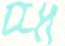

In [17]:
from IPython.display import clear_output

def testing():
    fileDir = '/root/Data/hangul_handwrite_val/image/test2'
    files = os.listdir(fileDir)

    max = 100
    cnt = 0

    for file in files:
        if cnt > max:
            break
        
        cnt += 1
        
        clear_output()
        imageFile = fileDir + "/" +file
        print(imageFile)

        img = tf.io.read_file(imageFile)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, (64, 64))

        print(img.shape)

        img = np.array(img)

        img = np.expand_dims(img, axis=0)

        #print(img.shape)

        ch, ju, jo = vit_classifier.predict(img)

        ch = ch.argmax()
        ju = ju.argmax()
        jo = jo.argmax()
        
        if ch <= 18:
            ja = label2ja[ch]
            mo = label2mo[ju]
            ba = label2ba[jo]
            
            if ju == 21:
                print(label2ja[ch])
                print(label2mo[ju])
                print(label2ba[jo])
            else:
                char = unicode.join_jamos_char(ja, mo ,ba)
                print(char)
        else:
            print(label2ja[ch])
        
        image = Image.open(imageFile)
        image.show()
        
        str = ""
        input(str)
        #os.system('cls')
        
        if (str == "exit"):
            exit()

    
testing()

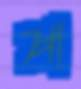

OUTLINER DETECTED
File :  /mnt/d/linData/synth3/train/images/29/299989.jpg , total :  9101
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
289889 File :  /mnt/d/linData/synth3/train/images/29/299984.jpg cnt :  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289890 File :  /mnt/d/linData/synth3/train/images/29/299979.jpg cnt :  3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289891 File :  /mnt/d/linData/synth3/train/images/29/299988.jpg cnt :  3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289892 File :  /mnt/d/linData/synth3/train/images/29/299992.jpg cnt :  3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289893 File :  /mnt/d/linData/synth3/train/images/29/299995.jpg cnt :  3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289894 File :  /mnt/d/linData/synth3/train/images/29/299996.jpg cnt :  2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289895 File :  /mnt/d/linData/synth3/train/images/29/299993.jpg cnt :  3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
289896 File :  /mnt/d/linData/synth3/train/images/29/299998.jpg cnt :  1
1/1 ━━━━━━━━━━━━━━━━━

In [15]:
from IPython.display import clear_output
import shutil

flt_csvFile = open("/mnt/d/linData/synth3/train/FullPathImageSynth3.csv", 'r', encoding='utf-8')
flt_reader = csv.reader(flt_csvFile)
flt_cnt = 0
flt_idx = 0
flt_max = 1000
flt_rm_cnt = 0

for line in flt_reader:
    if (flt_cnt > flt_max):
        break
    
    flt_hit = 0
    imgFile = line[0]
    
    if not os.path.exists(imgFile):
        continue
    
    img = Image.open(imgFile)
    img = img.resize((64,64))
    
    imgData = tf.image.convert_image_dtype(img, tf.float32)
    imgData = np.array(imgData)
    imgData = np.expand_dims(imgData, axis=0)
    
    ch, ju, jo = vit_classifier.predict(imgData)

    ch = ch.argmax()
    ju = ju.argmax()
    jo = jo.argmax()
    
    if (ch == int(line[1])):
        flt_hit += 1
    if (ju == int(line[2])):
        flt_hit += 1
    if (jo == int(line[3])):
        flt_hit += 1
    
    
    print(flt_idx, "File : ", imgFile, "cnt : ", flt_hit)
    flt_idx += 1
        
    if (flt_hit == 0):
        clear_output()
        flt_rm_cnt += 1
        #os.remove()
        displayImage = Image.open(imgFile)
        displayImage.show()
        
        baseName = os.path.basename(imgFile)
        shutil.copy(imgFile, "/mnt/d/linData/synth3/train/copy")
        
        os.remove(imgFile)
    
        print("OUTLINER DETECTED")
        #input()
        print("File : ", imgFile, ", total : ", flt_rm_cnt)

In [16]:
from IPython.display import clear_output
import shutil

flt_csvFile = open("/mnt/d/linData/synth2/train/FullPathImageSynth2.csv", 'r', encoding='utf-8')
flt_reader = csv.reader(flt_csvFile)
flt_cnt = 0
flt_idx = 0
flt_max = 1000
flt_rm_cnt = 0

for line in flt_reader:
    if (flt_cnt > flt_max):
        break
    
    flt_hit = 0
    imgFile = line[0]
    
    if not os.path.exists(imgFile):
        continue
    
    img = Image.open(imgFile)
    img = img.resize((64,64))
    
    imgData = tf.image.convert_image_dtype(img, tf.float32)
    imgData = np.array(imgData)
    imgData = np.expand_dims(imgData, axis=0)
    
    ch, ju, jo = vit_classifier.predict(imgData)

    ch = ch.argmax()
    ju = ju.argmax()
    jo = jo.argmax()
    
    if (ch == int(line[1])):
        flt_hit += 1
    if (ju == int(line[2])):
        flt_hit += 1
    if (jo == int(line[3])):
        flt_hit += 1
    
    
    #print(flt_idx, "File : ", imgFile, "cnt : ", flt_hit)
    flt_idx += 1
        
    if (flt_hit == 0):
        clear_output()
        flt_rm_cnt += 1
        #os.remove()
        # displayImage = Image.open(imgFile)
        # displayImage.show()
        
        baseName = os.path.basename(imgFile)
        shutil.copy(imgFile, "/mnt/d/linData/synth2/train/copy")
        
        os.remove(imgFile)
    
        print("OUTLINER DETECTED")
        #input()
        print("File : ", imgFile, ", total : ", flt_rm_cnt)

OUTLINER DETECTED
File :  /mnt/d/linData/synth2/train/images/28/281976.jpg , total :  12005
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
